# Lab8 — Solución: Regresión Logística 

Solución concisa y orientada a las preguntas planteadas en el laboratorio: ejemplos de clasificación lineal, fronteras no lineales mediante mapeo polinómico y aplicación al dataset `iris` (binaria y multiclase).

In [71]:
# Importaciones necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_circles, load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

## 1) Clasificación lineal — ejemplo simple
Generamos un dataset sintético separable linealmente con algo de ruido y entrenamos una regresión logística. Respondo: ¿cómo se interpreta $h_	heta(x)$ y la frontera de decisión?

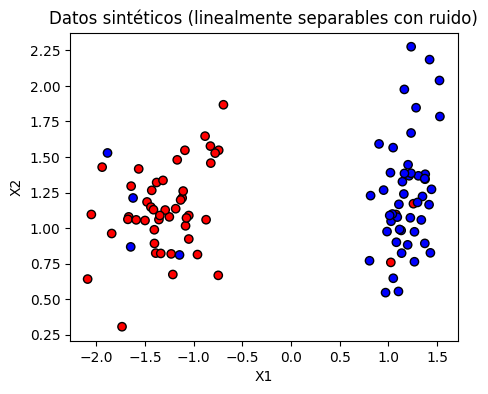

Coeficientes: [[-1.82562521 -0.11188862]] Intercept: [-0.03880297]


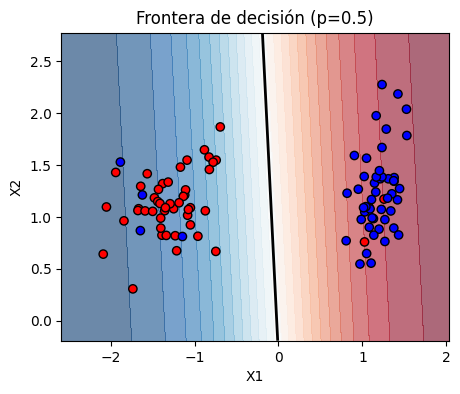

In [72]:
# Datos sintéticos lineales
X1, y1 = make_classification(n_features=2, n_redundant=0, n_informative=2, n_clusters_per_class=1, random_state=1, class_sep=1.2, flip_y=0.15)
plt.figure(figsize=(5,4))
plt.scatter(X1[:,0], X1[:,1], c=y1, cmap='bwr', edgecolor='k')
plt.title('Datos sintéticos (linealmente separables con ruido)')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

# Entrenar regresión logística y mostrar frontera lineal
clf = LogisticRegression(solver='lbfgs')
clf.fit(X1, y1)
print('Coeficientes:', clf.coef_, 'Intercept:', clf.intercept_)

# Dibujar frontera de decisión en 2D
xx = np.linspace(X1[:,0].min()-0.5, X1[:,0].max()+0.5, 200)
yy = np.linspace(X1[:,1].min()-0.5, X1[:,1].max()+0.5, 200)
XX, YY = np.meshgrid(xx, yy)
grid = np.c_[XX.ravel(), YY.ravel()]
probs = clf.predict_proba(grid)[:,1].reshape(XX.shape)
plt.figure(figsize=(5,4))
plt.contourf(XX, YY, probs, levels=25, cmap='RdBu', alpha=0.6)
plt.contour(XX, YY, probs, levels=[0.5], colors='k', linewidths=2)
plt.scatter(X1[:,0], X1[:,1], c=y1, cmap='bwr', edgecolor='k')
plt.title('Frontera de decisión (p=0.5)')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

**Explicación:**
- El modelo devuelve `predict_proba(x) = P(y=1|x;	heta)` que es $h_	heta(x)$.
- Se clasifica como clase 1 si $P(y=1|x) e 0.5$ (umbral por defecto), lo que corresponde a la curva `prob=0.5` en la gráfica.
- Los parámetros $heta$ se obtienen minimizando la función de coste (log-loss) mediante optimizadores como `lbfgs` en `sklearn`; no es necesario derivar manualmente en la práctica.

## 2) Fronteras no lineales — ejemplo con `make_circles`
Si los datos no son separables por un hiperplano, podemos transformar las características con polinomios y aplicar regresión logística sobre el espacio transformado.

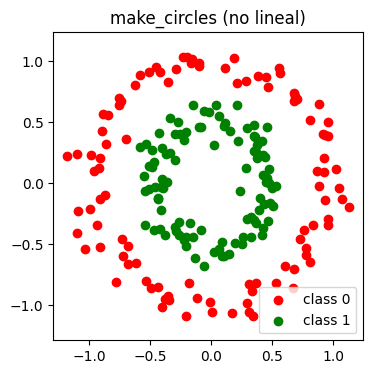

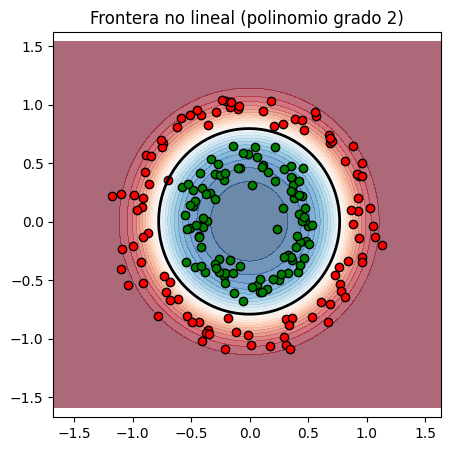

In [73]:
# Datos circulares (no lineales)
Xc, yc = make_circles(n_samples=200, factor=0.5, noise=0.08, random_state=0)
plt.figure(figsize=(4,4))
plt.scatter(Xc[yc==0,0], Xc[yc==0,1], c='r', label='class 0')
plt.scatter(Xc[yc==1,0], Xc[yc==1,1], c='g', label='class 1')
plt.legend()
plt.title('make_circles (no lineal)')
plt.axis('equal')
plt.show()

# Pipeline: PolynomialFeatures -> StandardScaler -> LogisticRegression
pipe = Pipeline([('poly', PolynomialFeatures(degree=2, include_bias=False)),
                 ('logreg', LogisticRegression(solver='lbfgs'))])
pipe.fit(Xc, yc)

# Mostrar frontera en el espacio original (mapeado por el clasificador)
xx = np.linspace(Xc[:,0].min()-0.5, Xc[:,0].max()+0.5, 300)
yy = np.linspace(Xc[:,1].min()-0.5, Xc[:,1].max()+0.5, 300)
XX, YY = np.meshgrid(xx, yy)
grid = np.c_[XX.ravel(), YY.ravel()]
probs = pipe.predict_proba(grid)[:,1].reshape(XX.shape)
plt.figure(figsize=(5,5))
plt.contourf(XX, YY, probs, levels=25, cmap='RdBu', alpha=0.6)
plt.contour(XX, YY, probs, levels=[0.5], colors='k', linewidths=2)
plt.scatter(Xc[yc==0,0], Xc[yc==0,1], c='r', edgecolor='k')
plt.scatter(Xc[yc==1,0], Xc[yc==1,1], c='g', edgecolor='k')
plt.title('Frontera no lineal (polinomio grado 2)')
plt.axis('equal')
plt.show()

**Explicación:**
- La transformación polinómica crea nuevas features (por ejemplo `x1^2`, `x1*x2`, `x2^2`) que permiten que un clasificador lineal en el espacio transformado represente fronteras curvas en el espacio original.
- El pipeline garantiza que la misma transformación se aplica en entrenamiento y predicción, y que las features quedan escaladas antes de aprender los parámetros.

## 3) Aplicación al dataset `iris` — multiclasificación y binarización
Respondemos las preguntas prácticas del laboratorio usando `sklearn.datasets.load_iris()` y mostrando pasos clave: EDA, partición estratificada, clasificación binaria (setosa vs no-setosa) y multiclasificación (softmax).

In [74]:
# Cargar iris y armar DataFrame
iris = load_iris()
df = pd.DataFrame(iris['data'], columns=[c.replace(' (cm)','').replace(' ','_') for c in iris['feature_names']])
df['target'] = iris['target']
df['target_name'] = [iris['target_names'][t] for t in df['target']]
display(df.head())
print('Descripción breve:')
print('\n'.join(iris['DESCR'].split('\n')[:5]))

,sepal_length,sepal_width,petal_length,petal_width,target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


Descripción breve:
.. _iris_dataset:

Iris plants dataset
--------------------



,sepal_length,sepal_width,petal_length,petal_width,target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


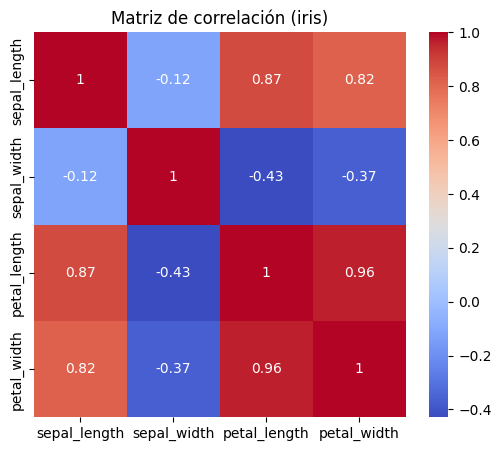

In [75]:
# Estadísticas y correlación rápida
display(df.describe())
plt.figure(figsize=(6,5))
plt.title('Matriz de correlación (iris)')
sns = __import__('seaborn')
sns.heatmap(df.drop(columns=['target','target_name']).corr(), annot=True, cmap='coolwarm')
plt.show()

### Partición estratificada — ¿Cómo se separan los datos?
Usamos `StratifiedShuffleSplit` sobre la columna `target` para preservar la proporción de clases en train/test. Esto evita sesgar el conjunto de test con respecto a la distribución original de clases (especialmente importante en datasets con clases desbalanceadas).

In [76]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in split.split(df, df['target']):
    strat_train = df.loc[train_idx].reset_index(drop=True)
    strat_test  = df.loc[test_idx].reset_index(drop=True)

print('Train size:', len(strat_train), 'Test size:', len(strat_test))
print('Proporciones en dataset completo:')
print(df['target'].value_counts(normalize=True).sort_index())
print('Proporciones en train:')
print(strat_train['target'].value_counts(normalize=True).sort_index())
print('Proporciones en test:')
print(strat_test['target'].value_counts(normalize=True).sort_index())

Train size: 120 Test size: 30
Proporciones en dataset completo:
target
0    0.333333
1    0.333333
2    0.333333
Name: proportion, dtype: float64
Proporciones en train:
target
0    0.333333
1    0.333333
2    0.333333
Name: proportion, dtype: float64
Proporciones en test:
target
0    0.333333
1    0.333333
2    0.333333
Name: proportion, dtype: float64


### Clasificación binaria: Setosa vs Rest (ejemplo práctico)
Construimos un clasificador binario donde la clase `setosa` se etiqueta como 1 y las otras como 0. Para visualización usaremos dos features (`sepal length`, `petal length`) y mostraremos la frontera de decisión.

Accuracy: 1.0
Classification report:
              precision    recall  f1-score   support

  not_setosa       1.00      1.00      1.00        20
      setosa       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



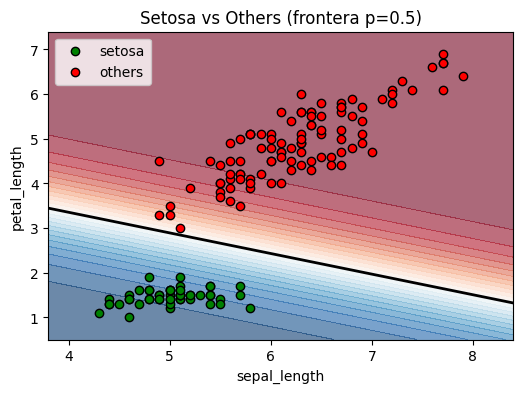

In [77]:
# Preparar datos binarios (setosa vs no-setosa)
X = df[['sepal_length','petal_length']].values
y_bin = (df['target']==0).astype(int).values  # 1=setosa, 0=others
X_train, X_test, y_train, y_test = train_test_split(X, y_bin, stratify=y_bin, test_size=0.2, random_state=42)
pipe_bin = Pipeline([('scaler', StandardScaler()), ('logreg', LogisticRegression())])
pipe_bin.fit(X_train, y_train)
y_pred = pipe_bin.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Classification report:')
print(classification_report(y_test, y_pred, target_names=['not_setosa','setosa']))

# Frontera en el espacio 2D
xx = np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 200)
yy = np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 200)
XX, YY = np.meshgrid(xx, yy)
grid = np.c_[XX.ravel(), YY.ravel()]
probs = pipe_bin.predict_proba(grid)[:,1].reshape(XX.shape)
plt.figure(figsize=(6,4))
plt.contourf(XX, YY, probs, levels=25, cmap='RdBu', alpha=0.6)
plt.contour(XX, YY, probs, levels=[0.5], colors='k', linewidths=2)
plt.scatter(X[y_bin==1,0], X[y_bin==1,1], c='g', label='setosa', edgecolor='k')
plt.scatter(X[y_bin==0,0], X[y_bin==0,1], c='r', label='others', edgecolor='k')
plt.xlabel('sepal_length')
plt.ylabel('petal_length')
plt.legend()
plt.title('Setosa vs Others (frontera p=0.5)')
plt.show()

### Multiclasificación (softmax) y probabilidad para una muestra dada
Entrenamos un clasificador multinomial (`multi_class='multinomial'`) sobre las 4 features y calculamos la probabilidad de la muestra solicitada `X=[4.9,5.0,1.8,0.3]`.

In [78]:
# Multiclasificación en las 4 features
X_all = df[[c for c in df.columns if c not in ['target','target_name']]].values
y_all = df['target'].values
scaler = StandardScaler()
Xs = scaler.fit_transform(X_all)
# Evitar pasar 'multi_class' por compatibilidad con algunas versiones de sklearn
log_multi = LogisticRegression(solver='lbfgs', max_iter=200)
log_multi.fit(Xs, y_all)
sample = np.array([[4.9,5.0,1.8,0.3]])
sample_s = scaler.transform(sample)
probs = log_multi.predict_proba(sample_s)[0]
for name, p in zip(iris['target_names'], probs):
    print(f'{name}: {p:.4f}')
print('Predicted class:', iris['target_names'][log_multi.predict(sample_s)[0]])

setosa: 0.9999
versicolor: 0.0001
virginica: 0.0000
Predicted class: setosa


**Interpretaciones y respuestas a preguntas teóricas:**
- La función de coste $J(	heta)$ usada (log-loss) proviene de la verosimilitud negativa y es adecuada porque, asumiendo independencia, maximizar la verosimilitud equivale a minimizar esta pérdida.
- La derivada de $J$ respecto a $	heta$ conduce al gradiente que permite aplicar gradiente descendente u optimizadores numéricos; sklearn emplea optimizadores robustos que evitan implementar manualmente el descenso por gradiente.
- La regularización (término $ambda$) penaliza coeficientes grandes y reduce sobreajuste; en `sklearn` se controla con el parámetro `C` (inversa de la regularización) y `penalty`.

**Recomendaciones prácticas:**
1) Para mejorar métricas: normalizar features, probar transformaciones polinómicas o interacciones, y explorar modelos no lineales (árboles/ensambles).
2) Para multiclasificación usar `multinomial` + `lbfgs` o `saga` (si datos grandes y sparse).


**Validación y curvas de aprendizaje**

A continuación ejecutamos validación cruzada para estimar la variabilidad del accuracy y trazamos las curvas de aprendizaje (train vs validation) para detectar sesgo/varianza. Usamos el clasificador de regresión logística sobre las 4 features estandarizadas (multiclase).

Accuracy CV (5-fold): [0.9667 1.     0.9333 0.9    1.    ]
Mean accuracy: 0.9600 ± 0.0389


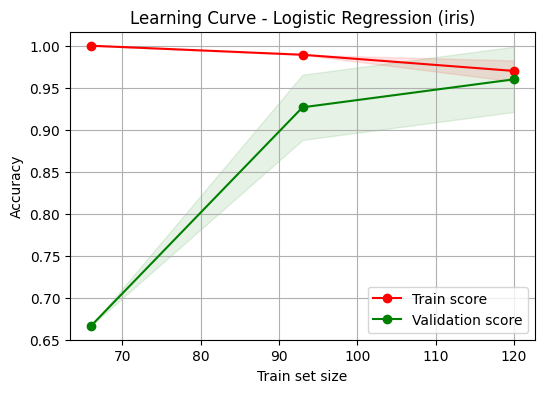

In [79]:
# Cross-validation y curvas de aprendizaje
from sklearn.model_selection import cross_val_score, learning_curve
from sklearn.linear_model import LogisticRegression

# Usamos el mismo escalador y los datos Xs, y_all ya definidos en el notebook
est = LogisticRegression(solver='lbfgs', max_iter=500)

# cross_val_score (accuracy)
scores = cross_val_score(est, Xs, y_all, cv=5, scoring='accuracy', n_jobs=-1)
print('Accuracy CV (5-fold):', np.round(scores, 4))
print('Mean accuracy: {:.4f} ± {:.4f}'.format(scores.mean(), scores.std()))

# Curvas de aprendizaje
train_sizes = np.linspace(0.1, 1.0, 5)
train_sizes, train_scores, valid_scores = learning_curve(est, Xs, y_all, cv=5, train_sizes=train_sizes, scoring='accuracy', n_jobs=-1)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
valid_scores_mean = np.mean(valid_scores, axis=1)
valid_scores_std = np.std(valid_scores, axis=1)

plt.figure(figsize=(6,4))
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, valid_scores_mean - valid_scores_std, valid_scores_mean + valid_scores_std, alpha=0.1, color='g')
plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Train score')
plt.plot(train_sizes, valid_scores_mean, 'o-', color='g', label='Validation score')
plt.xlabel('Train set size')
plt.ylabel('Accuracy')
plt.title('Learning Curve - Logistic Regression (iris)')
plt.legend(loc='best')
plt.grid(True)
plt.show()